## 3. Logistic Regression

### 3.1 Packages importeren 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


from scipy import stats

from preprocessing import(
    spacy_preprocessor,
    spacy_tokenizer,
)
from helpfuncties import load_dataset

### 3.2 Dataset inladen 

In [7]:
df = load_dataset()
y = df['Product']
X = df['Omschrijving']

### 3.3 Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

train_df = pd.DataFrame({
    "Omschrijving": X_train,
    "Product": y_train
})

test_df = pd.DataFrame({
    "Omschrijving": X_test,
    "Product": y_test
})

train_df.to_csv("train.csv", index=True)
test_df.to_csv("test.csv", index=True)

### 3.4 Pipeline + Hyperparameter Tuning

#### 3.4.1 TF-IDF en Logistic Regression Pipeline

In [9]:
tfidf = TfidfVectorizer( # TF-IDF vectorizer met de preprocesser en tokenizer van hierboven 
        preprocessor=spacy_preprocessor,
        tokenizer=spacy_tokenizer,
        analyzer='word', # werkt op woord niveau (geen characters, geen zinnen)
        ngram_range=(1,2), # unigrams = 'credit', bigrams = 'credit card'. Verbetert de prestaties van het mmodel 
        token_pattern=None # None want danb word onze custom tokenizer gebruikt
    )

In [10]:
model = LogisticRegression(max_iter=10000, class_weight='balanced', n_jobs=-1) # Logistische regressie model met gebalanceerde klassengewichten

logreg_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('model', model)])   

#### 3.4.2 RandomizedSearchCV

In [11]:
random_params = {
    'model__C': stats.loguniform(1e-3, 200),
    'model__class_weight': ['balanced', None],
    'model__solver': ['lbfgs', 'saga'],
    'tfidf__min_df': [1, 2, 3, 4, 5],
    'tfidf__max_df': [0.75, 0.8, 0.9, 1.0],
    'tfidf__ngram_range': [(1,1), (1,2), (1,3)],
    'tfidf__max_features': [30000, 50000, None],
    'tfidf__sublinear_tf': [True, False],
    'tfidf__norm': ['l2', None],
    'tfidf__binary': [False, True],
    'tfidf__use_idf': [True, False]
}

random_search = RandomizedSearchCV(
    logreg_pipeline,
    param_distributions=random_params,
    n_iter=80,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)
best = random_search.best_params_

Fitting 3 folds for each of 80 candidates, totalling 240 fits


ValueError: 
All the 240 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
240 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/odessa/Desktop/Applied Data Science & AI/2_Dataproject 1 /Dataproject1_code/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/odessa/Desktop/Applied Data Science & AI/2_Dataproject 1 /Dataproject1_code/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/odessa/Desktop/Applied Data Science & AI/2_Dataproject 1 /Dataproject1_code/.venv/lib/python3.13/site-packages/sklearn/

#### 3.4.3 GridSearchCV

In [ ]:
grid_params = {
    'model__C': [
        best['model__C'] * 0.5,
        best['model__C'],
        best['model__C'] * 2
    ],
    'model__class_weight': [best['model__class_weight']],
    'model__solver': [best['model__solver']],
    
    'tfidf__min_df': [
        max(1, best['tfidf__min_df'] - 1),
        best['tfidf__min_df'],
        best['tfidf__min_df'] + 1
    ],
    'tfidf__max_df': [best['tfidf__max_df']],
    'tfidf__ngram_range': [best['tfidf__ngram_range']],
    'tfidf__max_features': [best['tfidf__max_features']],
    'tfidf__sublinear_tf': [best['tfidf__sublinear_tf']],
    'tfidf__norm': [best['tfidf__norm']],
    'tfidf__binary': [best['tfidf__binary']],
    'tfidf__use_idf': [best['tfidf__use_idf']]
}

In [ ]:
grid = GridSearchCV(
    logreg_pipeline,
    param_grid=grid_params,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
logreg_pipeline = grid.best_estimator_

print("\nBeste Parameters GridSearch: ")
print(grid.best_params_)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


### 3.5 Evaluatie Modelprestaties 

#### 3.5.1 Voorspellingen

In [ ]:
y_pred = logreg_pipeline.predict(X_test)
y_proba = logreg_pipeline.predict_proba(X_test)

#### 3.5.2 Classification report

In [ ]:
print("\nClassification Report Logistic Regression:\n")
print(classification_report(y_test, y_pred))

Testset Classification Report Logistic Regression:
                    precision    recall  f1-score   support

      Bankrekening       0.89      0.85      0.87       446
Consumentenkrediet       0.76      0.58      0.66       284
        Creditcard       0.83      0.82      0.82       564
         Hypotheek       0.92      0.94      0.93       994
           Incasso       0.83      0.88      0.85      1223
Kredietregistratie       0.83      0.84      0.84       934

          accuracy                           0.85      4445
         macro avg       0.84      0.82      0.83      4445
      weighted avg       0.85      0.85      0.85      4445



#### 3.5.3 Confusion Matrix

[[ 378    2   35   13   12    6]
 [   7  165   15   20   54   23]
 [  20   11  462    6   35   30]
 [  12    6    6  936   18   16]
 [   8   16   20   26 1072   81]
 [   1   17   21   15   96  784]]


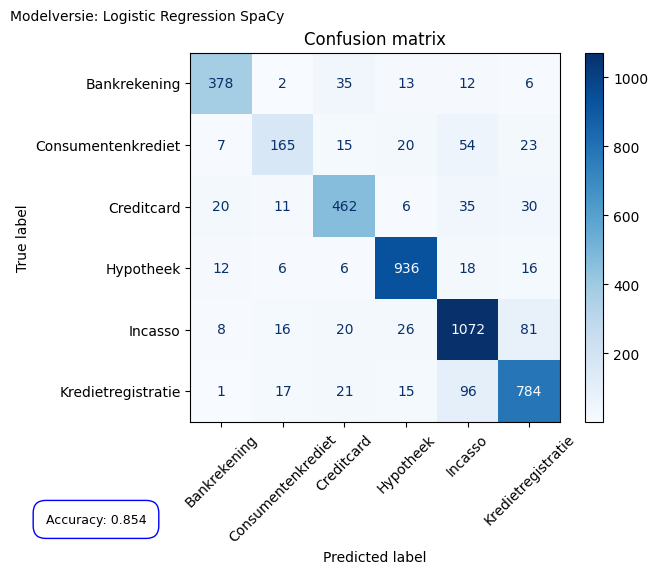

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)

plt.xticks(rotation=45)
plt.title('Confusion matrix Logistic Regression')
plt.savefig("afbeeldingen/confusion_matrix_logreg.png", dpi=300, bbox_inches='tight') 
plt.show()

### 3.5.4 Conclusie modelprestatie 

-----